In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import os
import re
from pycontrails.core import GeoVectorDataset
from pycontrails.models.gpat.gpat import create_jobs_df, filter_jobs_df, load_fl_df, load_pl_df, load_chem_ds, load_chem_da, plot_heatmap, anim_chem, mc_test, boxm_test

In [2]:
outputs_dir = f"{os.getcwd()}/outputs/"

In [3]:
# Filter criteria
criteria = {
        # "n_ac": 3,
        # "rt_fl": (pd.Timedelta(minutes=30), pd.Timedelta(hours=2)),
        # "date_created": (pd.Timestamp("2024-11-16"), pd.Timestamp("2024-11-17")),
        # "job_id": ['sensitivity_NA_1_1000_0_2_0.01_0.05', 
        #            'sensitivity_NA_2_1000_0_2_0.01_0.05',
        #            'sensitivity_NA_5_1000_0_2_0.01_0.05',]
        "job_id": ['id_vs_plume_NA_10_2000_0_2_0.05_0.05']

    }

In [4]:
jobs_df = create_jobs_df(outputs_dir)

jobs_df

,t0_fl,rt_fl,ts_fl,ac_type,fl0_speed,fl0_heading,fl0_coords0,sep_dist,n_ac,dt_integration,...,traj_gen_proc,gen_met_proc,bg_chem_proc,ac_perf_proc,emissions_proc,sim_plumes_proc,plume_to_grid_proc,run_cc_proc,run_boxm_proc,gen_outputs_proc
job_id,,,,,,,,,,,,,,,,,,,,,
sensitivity_NA_2_1000_0_2_0.01_0.05,2022-01-20 13:00:00,0 days 01:00:00,0 days 00:02:00,A320,100.0,45.0,"(47.1, -32.9, 12500)","(1000, 0, 0)",2,0 days 00:02:00,...,0.012016,5.372012,0.295543,0.045942,0.085317,1.275117,647.217342,1.354000e-06,8.441803,0
sensitivity_EU_5_1000_0_2_0.01_0.05,2022-05-20 13:00:00,0 days 01:00:00,0 days 00:02:00,A320,100.0,45.0,"(42.1, 7.1, 8500.0)","(1000, 0, 0)",5,0 days 00:02:00,...,0.013300,5.426132,0.287380,0.096320,0.175618,2.008644,1774.873879,1.322000e-06,8.325467,0
sensitivity_US_1_1000_0_2_0.01_0.05,2022-11-10 13:00:00,0 days 01:00:00,0 days 00:02:00,A320,100.0,45.0,"(37.1, -96.9, 6500.0)","(1000, 0, 0)",1,0 days 00:02:00,...,0.022383,5.058099,0.280728,0.029531,0.061309,1.120666,394.541601,1.312000e-06,8.007263,0
sensitivity_EU_1_1000_0_2_0.01_0.05,2022-05-20 13:00:00,0 days 01:00:00,0 days 00:02:00,A320,100.0,45.0,"(42.1, 7.1, 8500.0)","(1000, 0, 0)",1,0 days 00:02:00,...,0.012420,5.425169,0.284893,0.028583,0.055773,1.010577,386.019590,1.229000e-06,8.347543,0
sensitivity_US_5_1000_0_2_0.01_0.05,2022-11-10 13:00:00,0 days 01:00:00,0 days 00:02:00,A320,100.0,45.0,"(37.1, -96.9, 6500.0)","(1000, 0, 0)",5,0 days 00:02:00,...,0.013036,5.054129,0.287160,0.099957,0.180542,2.046812,1956.666829,1.164000e-06,8.006458,0
id_vs_plume_NA_10_1000_0_2_0.01_0.05,2022-01-20 13:00:00,0 days 01:00:00,0 days 00:02:00,A320,100.0,45.0,"(47.1, -32.9, 12500)","(0, 0, 0)",10,0 days 00:02:00,...,0.013753,5.363501,0.278070,0.180101,0.326307,3.255747,3118.299986,9.989999e-07,8.259106,0
id_vs_plume_NA_3_1000_0_ID_0.01_0.05,2022-01-20 13:00:00,0 days 01:00:00,0 days 00:02:00,A320,100.0,45.0,"(47.1, -32.9, 12500)","(0, 0, 0)",3,0 days 00:02:00,...,0.012012,5.375938,0.279309,0.061991,0.115117,0.878836,7.157876,1.092000e-06,8.239275,0
id_vs_plume_NA_1_1000_0_ID_0.01_0.05,2022-01-20 13:00:00,0 days 01:00:00,0 days 00:02:00,A320,100.0,45.0,"(47.1, -32.9, 12500)","(0, 0, 0)",1,0 days 00:02:00,...,0.016138,5.412613,0.283305,0.030330,0.064858,0.930789,7.167538,1.069000e-06,8.276019,0
sensitivity_US_2_1000_0_2_0.01_0.05,2022-11-10 13:00:00,0 days 01:00:00,0 days 00:02:00,A320,100.0,45.0,"(37.1, -96.9, 6500.0)","(1000, 0, 0)",2,0 days 00:02:00,...,0.011953,5.044921,0.287131,0.046108,0.083980,1.251759,786.053114,1.310000e-06,8.007347,0


In [5]:
filtered_df = filter_jobs_df(jobs_df, criteria)

job_ids = filtered_df.index.values
 
filtered_df



,t0_fl,rt_fl,ts_fl,ac_type,fl0_speed,fl0_heading,fl0_coords0,sep_dist,n_ac,dt_integration,...,traj_gen_proc,gen_met_proc,bg_chem_proc,ac_perf_proc,emissions_proc,sim_plumes_proc,plume_to_grid_proc,run_cc_proc,run_boxm_proc,gen_outputs_proc
job_id,,,,,,,,,,,,,,,,,,,,,
id_vs_plume_NA_10_2000_0_2_0.05_0.05,2022-01-20 13:00:00,0 days 01:00:00,0 days 00:02:00,A320,100.0,45.0,"(47.1, -32.9, 12500)","(2000.0, 0.0, 0.0)",10,0 days 00:02:00,...,0.01548,5.490894,0.2984,0.1821,0.338983,3.359405,981.057774,0.000001,9.838246,0


In [6]:
fl_df = load_fl_df(job_ids, outputs_dir)

fl_df

plume_time_data = GeoVectorDataset(data=fl_df.loc[fl_df["time"] == fl_df["time"].min()])



In [7]:
pl_df = load_pl_df(job_ids, outputs_dir)
pl_df.columns

pl_df

,flight_id,waypoint,fuel_flow,fuel_burn,true_airspeed,CO2,H2O,SO2,NO,NO2,...,longitude,latitude,level,width,heading,sigma_yy,sigma_zz,sin_a,cos_a,altitude
job_id,,,,,,,,,,,,,,,,,,,,,
id_vs_plume_NA_10_2000_0_2_0.05_0.05,0.0,0,1.039642,124.757011,100.099398,394.232154,153.451123,0.104796,1.712263,0.090119,...,-32.900000,47.100000,178.645172,322.694540,NaN,1.301647e+04,433.664232,NaN,NaN,12500.0
id_vs_plume_NA_10_2000_0_2_0.05_0.05,1.0,0,1.039620,124.754388,100.087276,394.223865,153.447897,0.104794,1.712209,0.090116,...,-32.881366,47.112719,178.645172,322.692638,NaN,1.301632e+04,433.651441,NaN,NaN,12500.0
id_vs_plume_NA_10_2000_0_2_0.05_0.05,2.0,0,1.039598,124.751758,100.075153,394.215554,153.444662,0.104791,1.712155,0.090113,...,-32.862728,47.125439,178.645172,322.690734,NaN,1.301616e+04,433.638645,NaN,NaN,12500.0
id_vs_plume_NA_10_2000_0_2_0.05_0.05,3.0,0,1.039576,124.749121,100.063029,394.207223,153.441419,0.104789,1.712100,0.090111,...,-32.844086,47.138158,178.645172,322.688830,NaN,1.301601e+04,433.625843,NaN,NaN,12500.0
id_vs_plume_NA_10_2000_0_2_0.05_0.05,4.0,0,1.039554,124.746478,100.050904,394.198870,153.438168,0.104787,1.712046,0.090108,...,-32.825439,47.150877,178.645172,322.686925,NaN,1.301586e+04,433.613035,NaN,NaN,12500.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
id_vs_plume_NA_10_2000_0_2_0.05_0.05,9.0,6,1.038740,124.648860,99.627831,393.890397,153.318098,0.104705,1.710043,0.090002,...,-32.054226,47.669913,178.645172,53144.779447,NaN,3.530459e+08,7547.352669,NaN,NaN,12500.0
id_vs_plume_NA_10_2000_0_2_0.05_0.05,0.0,7,1.038809,124.657109,99.664701,393.916464,153.328244,0.104712,1.710212,0.090011,...,-32.109103,47.631346,178.645172,53152.154476,NaN,3.531439e+08,7549.621023,NaN,NaN,12500.0
id_vs_plume_NA_10_2000_0_2_0.05_0.05,1.0,7,1.038786,124.654276,99.652542,393.907513,153.324760,0.104710,1.710154,0.090008,...,-32.090470,47.644066,178.645172,53149.643417,NaN,3.531106e+08,7548.848655,NaN,NaN,12500.0


In [8]:
chem_ds = load_chem_ds(job_ids, outputs_dir)


/user/home/kt16229/BOXM/scratch/miniconda3/envs/contrails/lib/python3.12/site-packages/xarray/backends/plugins.py:80: RuntimeWarning: Engine 'cfgrib' loading failed:
Cannot find the ecCodes library
  warnings.warn(f"Engine {name!r} loading failed:\n{ex}", RuntimeWarning)


<xarray.DataArray 'Y' ()> Size: 8B
array(0.59953781)
Coordinates:
    level         float64 8B 178.6
    longitude     float64 8B -32.9
    latitude      float64 8B 47.1
    air_pressure  float64 8B ...
    altitude      float64 8B ...
    species_out   <U4 16B 'NO'

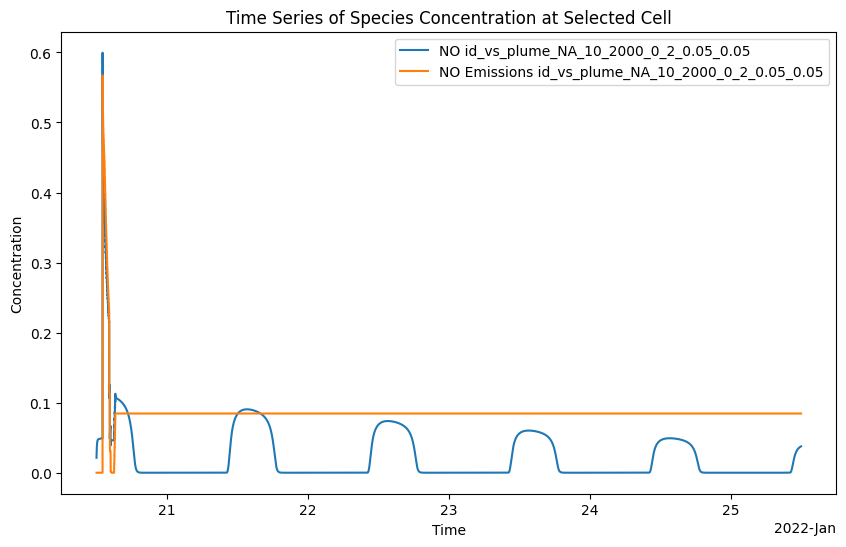

In [15]:
chem_da = []
emi_da = []
# Create a figure and axis for plotting
fig, ax = plt.subplots(figsize=(10, 6))

for job, ds in enumerate(chem_ds):
    chem_ds[job] = chem_ds[job].assign_coords(species_out=chem_ds[job].attrs["species_out"])
    chem_da.append(chem_ds[job]["Y"])

    emi_da.append(chem_ds[job]["emi"])

    chem_da_cell = chem_da[job].sel(level=chem_da[0].level[1], longitude=-32.9, latitude=47.1, method='nearest')
    emi_da_cell = emi_da[job].sel(level=emi_da[0].level[1], longitude=-32.9, latitude=47.1, method='nearest')

    NO_data = chem_da_cell.sel(species_out="NO")
    NO2_data = chem_da_cell.sel(species_out="NO2")
    O3_data = chem_da_cell.sel(species_out="O3")

    NO_emi_data = emi_da_cell.sel(emi_species="NO")
    NO2_emi_data = emi_da_cell.sel(emi_species="NO2")

    # Plot the time series data
    NO_data.plot(ax=ax, label=f"NO {chem_da_cell['job_id'].values[0]}")
    NO_emi_data.plot(ax=ax, label=f"NO Emissions {emi_da_cell['job_id'].values[0]}")

# Add labels and legend
ax.set_xlabel('Time')
ax.set_ylabel('Concentration')
ax.set_title('Time Series of Species Concentration at Selected Cell')
ax.legend()

# plt.show()
pd.set_option('display.max_rows', 500)
NO_df = NO_data.to_dataframe()
NO_df

NO_data.max()


In [ ]:

# chem_ds_stacked = chem_ds.stack(
#             {"cell": ["level", "longitude", "latitude"]}
#         )
# chem_ds_stacked = chem_ds_stacked.reset_index("cell")

# chem_ds_stacked


In [10]:

# max_emi_cell = chem_ds_stacked["emi"].mean(dim="time").argmax()#.item()
# print(max_emi_cell)
# # find cell that has max emissions averaged over time in it
# cell_chem_ds = chem_ds_stacked.sel(job_id=job_ids[0], cell=max_emi_cell)
# cell_chem_ds
# # Select the emissions for the specified species
# emi_data = cell_chem_ds["emi"].sel(emi_species="NO")
# chem_data = cell_chem_ds["Y"].sel(species_out="NO")
# emi_data.plot()
# chem_data.plot()

# # # Convert time and emi data to pandas Series
# # ts = 0
# # time_series = pd.Series(emi_data["time"].values)
# # emi_series = pd.Series(emi_data.values)

# # # Print time and emi values side by side
# # for time, emi in zip(time_series, emi_series):
# #     ts += 1
# #     print(f"TS: {ts}, Time: {time}, EMI: {emi}")

# for s, species in enumerate(chem_ds["species"].values):
#     print(chem_ds["bg_chem"].isel(level=1,latitude=0,longitude=0, species=s).values)



<xarray.DataArray 'emi' (time: 1000, longitude: 22, latitude: 21)> Size: 4MB
array([[[0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        ...,
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ]],

       [[0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
...
        [0.08451541, 0.08451743, 0.08451

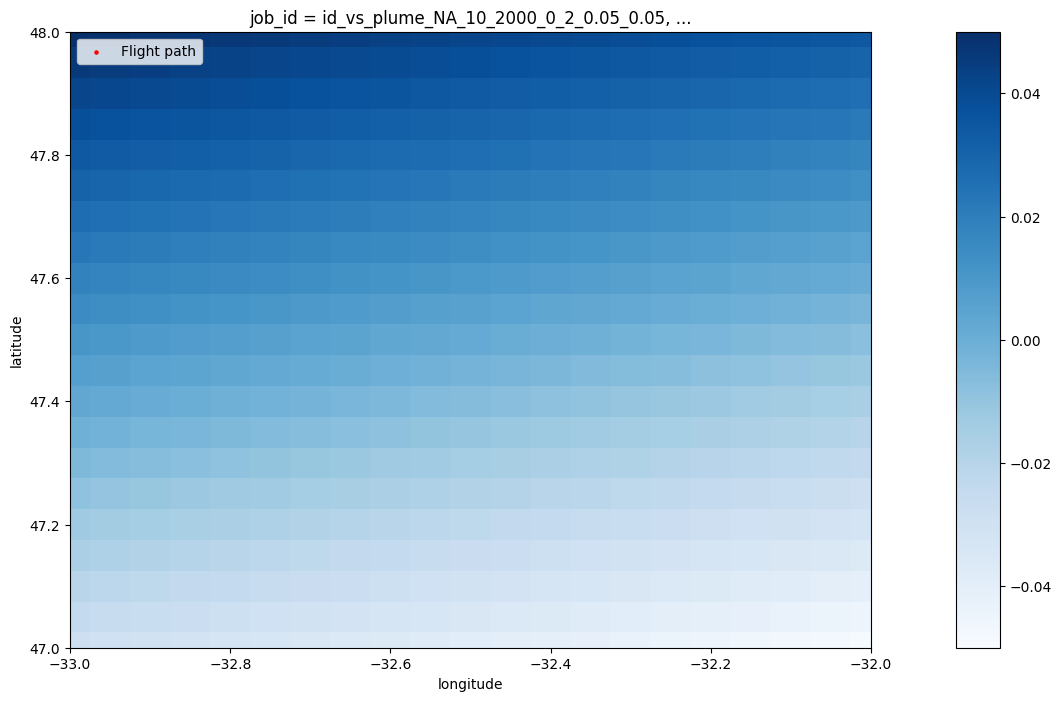

In [11]:
anim_chem(job_ids[0], jobs_df, fl_df, pl_df, chem_ds[0], var1="emi", var2="NO", level=chem_da[0].level[1], resample_freq="2min")

In [12]:
# vecmass, gridmass, mc = mc_test(job_ids[0], jobs_df, fl_df, pl_df, chem_ds)
# mc

In [13]:
path = '/user/work/kt16229/pycontrails_kt/pycontrails/models/gpat/'

cell_chem_ds = boxm_test(path, job_ids[0], 0, chem_ds)

# dj_data = cell_chem_ds["DJ"].sel(photol_coeffs=3)
# dj_orig_data = cell_chem_ds["DJ_orig"].sel(photol_coeffs=3)
# dj_data.plot()
# dj_orig_data.plot()

chem_data = cell_chem_ds["Y"].sel(species_out="NO")
chem_orig_data = cell_chem_ds["Y_orig"].sel(species_out="NO")
chem_data.plot()
chem_orig_data.plot()


AttributeError: 'list' object has no attribute 'stack'